# Declaration of Originality

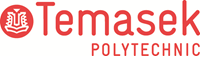

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Aaqil Shakir
* Tutorial Group                :  P07
* Tutor						    :  Ester Goh
* Submission Date               : 



**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [79]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from scipy.stats import randint, uniform
import joblib
import os
import json


# 1. Business Understanding
Goal: 
Predict whether a loan is approved or rejected


# 2. Data Understanding

## 2.1 Load dataset

In [80]:
## Read *.csv file into pandas DataFrame
FILE_PATH = 'loan_approval_dataset.csv'
df = pd.read_csv(FILE_PATH)



## 2.2 Summary Statistics

In [81]:
# Display first few rows to understand the dataset structure
df.head()



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


This step is used to inspect the initial rows of the dataset in order to understand its structure, feature names, and sample values, ensuring that the data has been loaded correctly before proceeding with data cleaning and exploratory analysis.

In [82]:
# Check number of rows and columns
df.shape

(4269, 13)

This step is performed to determine the dimensionality of the dataset by identifying the number of rows and columns, which helps assess dataset size and confirms that the data aligns with expectations before further preprocessing and modelling.

In [83]:
## Understand the type of variable for each column
df.dtypes

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

This step is used to identify the data type of each feature, allowing appropriate preprocessing decisions such as encoding categorical variables and scaling numerical variables before model training.

In [84]:
# Count the number of occurrences for each class in the target variable
df[' loan_status'].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

This step examines the distribution of the target variable to identify potential class imbalance, which is important for selecting appropriate evaluation metrics and ensuring that the model does not become biased toward the majority class during training.

In [85]:
# Generate summary statistics such as mean, min, max, and standard deviation
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


This step provides summary statistics for numerical features, enabling an initial assessment of data ranges, variability, and potential anomalies, which supports informed decisions during data cleaning and feature engineering.

In [86]:
## Check for missing data
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

This step is used to identify missing values across all features, allowing appropriate handling strategies to be applied and ensuring data completeness before proceeding with model training.

In [87]:
## Describe data distribution
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


This step provides an overview of the dataset’s structure, including feature data types and non-null counts, which helps verify data integrity and informs subsequent preprocessing decisions such as encoding and scaling.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

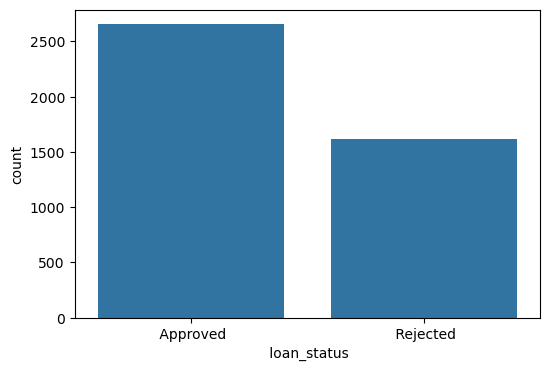

In [88]:
## Understanding distribution of target
plt.figure(figsize=(6, 4))
sns.countplot(x=' loan_status', data=df)
plt.xticks(rotation=0)
plt.show()




Observation:
The target variable loan_status shows a moderate class imbalance, with a higher number of approved loans compared to rejected loans. This indicates that the dataset contains more positive outcomes than negative outcomes.

Justification:
Visualising the distribution of the target variable helps identify class imbalance, which is critical for model evaluation and selection of appropriate metrics. Since the classes are not evenly distributed, relying solely on accuracy may be misleading, and metrics such as precision, recall, and F1-score are more suitable for assessing model performance in this loan approval context.

### 2.3.1.2 Understanding distribution of features

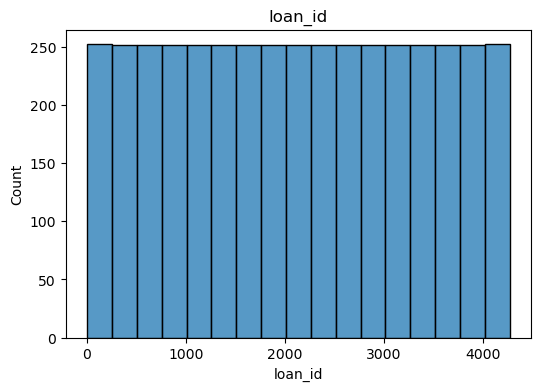

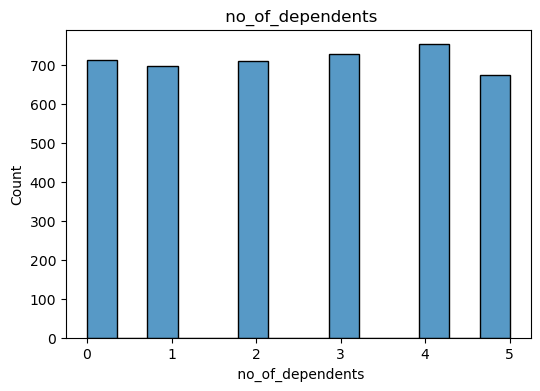

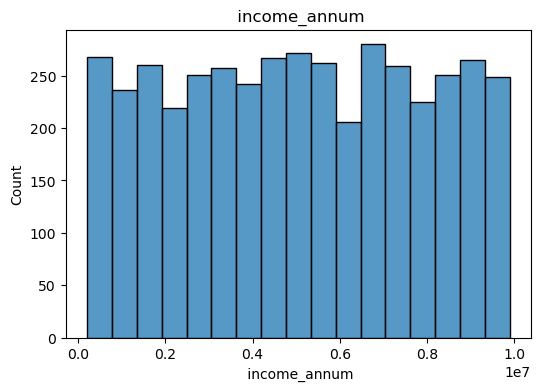

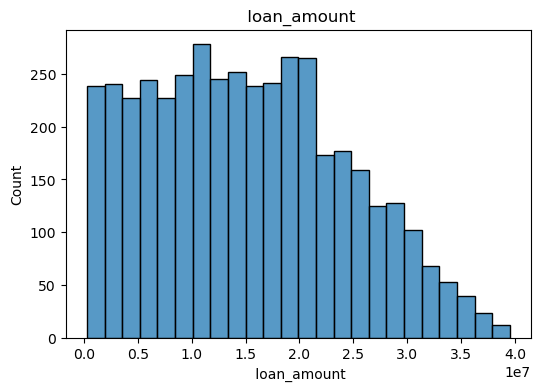

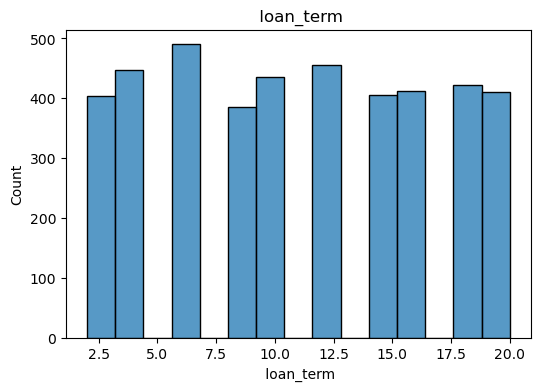

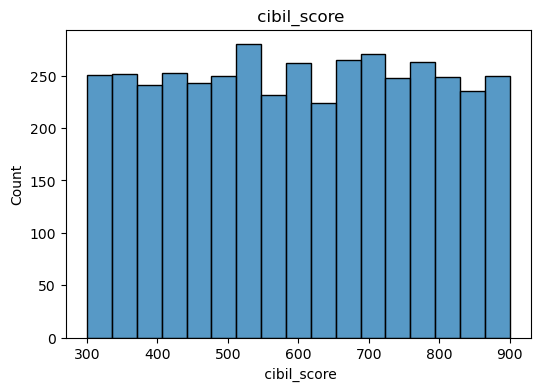

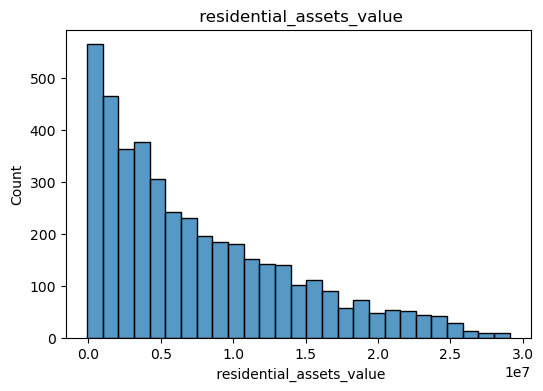

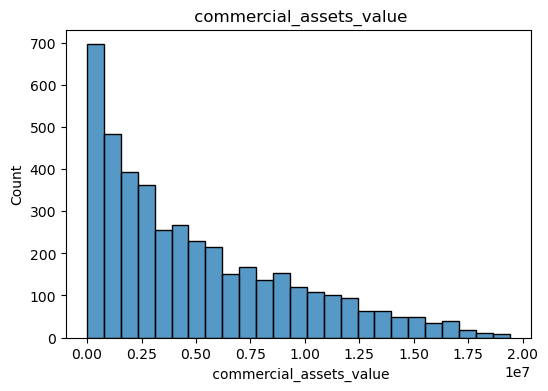

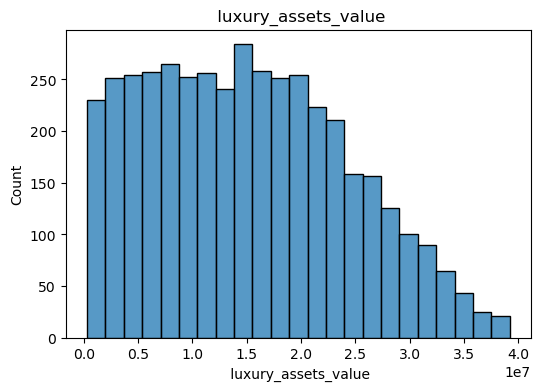

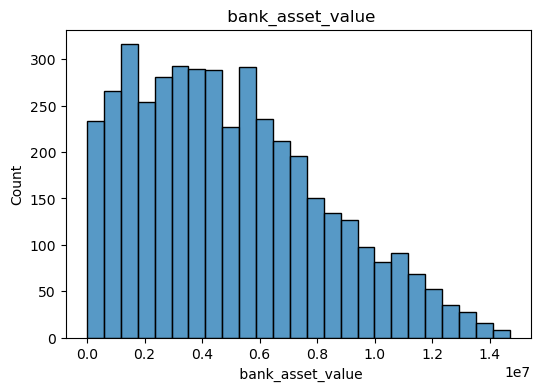

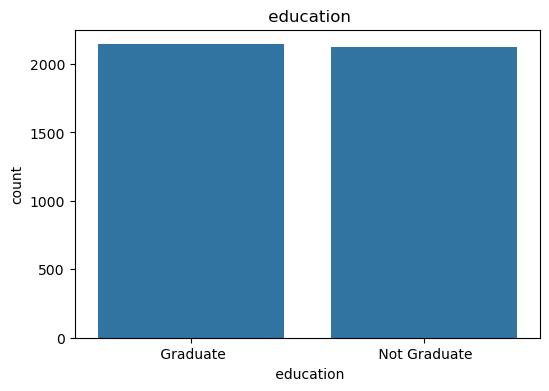

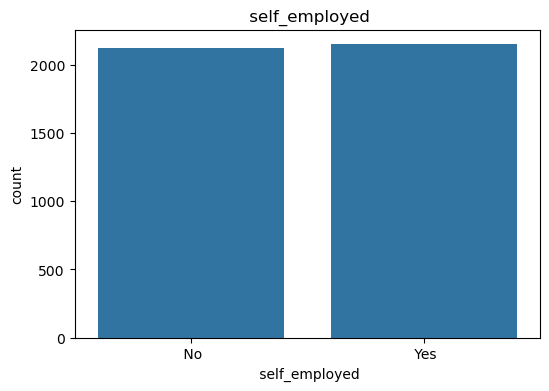

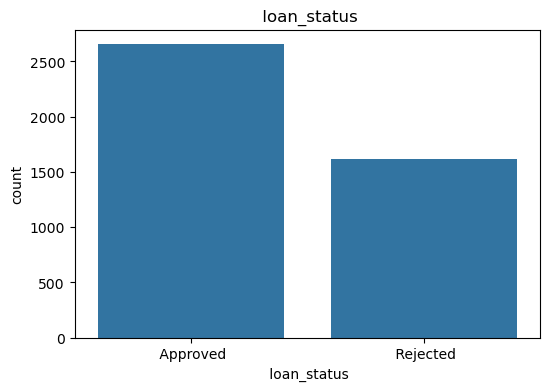

In [89]:
## Understanding distribution of features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in numeric_cols]

for c in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[c], kde=False)
    plt.title(c)
    plt.show()

for c in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=c, data=df)
    plt.title(c)
    plt.xticks(rotation=0)
    plt.show()




loan_id (Histogram)

Observation:
The distribution of loan_id appears uniform across the dataset, indicating that it is an identifier rather than a meaningful numerical feature.

Justification:
This visualisation confirms that loan_id does not carry predictive information and should be excluded from modelling to prevent introducing noise into the learning process.

no_of_dependents (Histogram)

Observation:
The number of dependents ranges from 0 to 5 and is relatively evenly distributed, with no extreme skewness or outliers.

Justification:
Understanding the spread of dependents helps assess its potential influence on loan approval decisions and confirms that it can be treated as a valid numerical feature during modelling.

income_annum (Histogram)

Observation:
Annual income spans a wide range and shows a relatively even distribution, indicating substantial variability among applicants’ earning levels.

Justification:
Visualising income distribution highlights its scale and variability, supporting the need for feature scaling and potential transformation before training distance-sensitive models such as Logistic Regression.

loan_amount (Histogram)

Observation:
Loan amounts are right-skewed, with more applicants requesting smaller loans and fewer requesting very large amounts.

Justification:
This distribution suggests that loan amount may influence approval outcomes differently across ranges and reinforces the importance of scaling to prevent larger values from dominating the model.

loan_term (Histogram)

Observation:
Loan terms are discrete and distributed across several common durations, with no single term overwhelmingly dominant.

Justification:
This confirms that loan term can be treated as a numerical feature while preserving its discrete nature, allowing the model to learn temporal repayment patterns.

cibil_score (Histogram)

Observation:
CIBIL scores are broadly distributed between lower and higher values, showing meaningful variation in applicants’ creditworthiness.

Justification:
Since credit score is a key indicator of repayment risk, visualising its distribution validates its importance as a predictive feature for loan approval.

residential_assets_value (Histogram)

Observation:
Residential asset values are right-skewed, with a large number of applicants having lower asset values and fewer with very high assets.

Justification:
This skewed distribution suggests the presence of high-value outliers, supporting the need for scaling or transformation to ensure stable model training.

commercial_assets_value (Histogram)

Observation:
Commercial asset values show strong right skewness, indicating that most applicants hold relatively low commercial assets.

Justification:
Understanding this skew helps justify preprocessing steps such as scaling to prevent extreme values from disproportionately influencing the model.

luxury_assets_value (Histogram)

Observation:
Luxury asset values display a wide spread with fewer high-value observations, suggesting variability in discretionary wealth among applicants.

Justification:
This feature may provide additional financial context beyond income and supports inclusion in the model after appropriate preprocessing.

bank_asset_value (Histogram)

Observation:
Bank asset values are moderately right-skewed, with most applicants holding lower balances and fewer holding large reserves.

Justification:
Visualising this feature confirms the need for scaling and supports its relevance as an indicator of financial stability.

education (Count Plot)

Observation:
The number of graduate and non-graduate applicants is relatively balanced, indicating no strong dominance of a single category.

Justification:
This balance suggests that education level can be encoded without introducing significant class bias during training.

self_employed (Count Plot)

Observation:
Self-employed and non-self-employed applicants are present in similar proportions.

Justification:
The relatively even distribution indicates that employment type is a meaningful categorical feature and should be retained for modelling.

loan_status (Count Plot)

Observation:
Approved loans are more frequent than rejected loans, indicating a moderate class imbalance in the target variable.

Justification:
This observation highlights the need for evaluation metrics beyond accuracy, such as precision, recall, and F1-score, to properly assess model performance in a loan approval context.

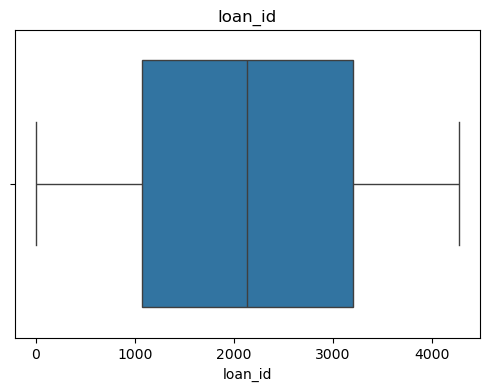

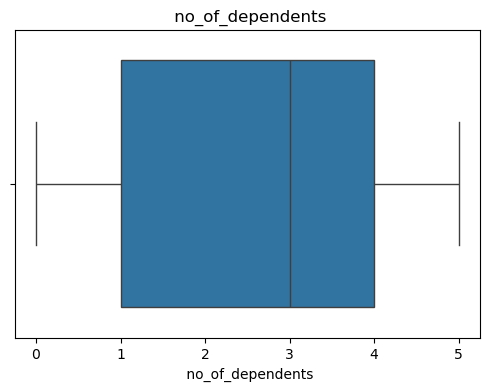

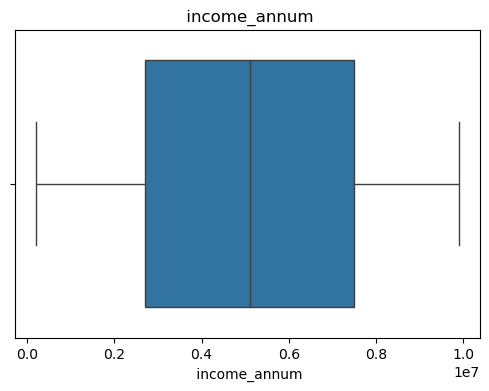

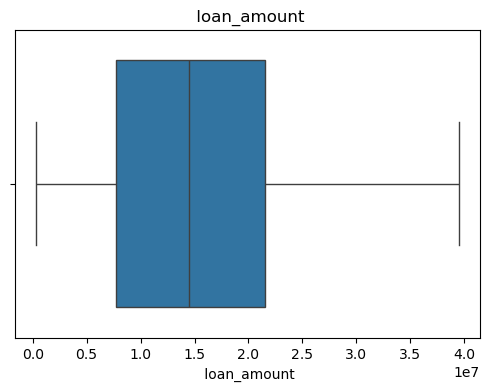

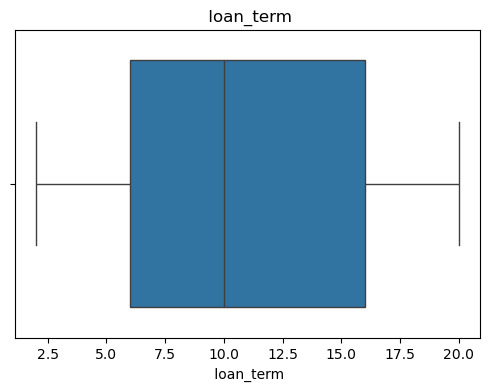

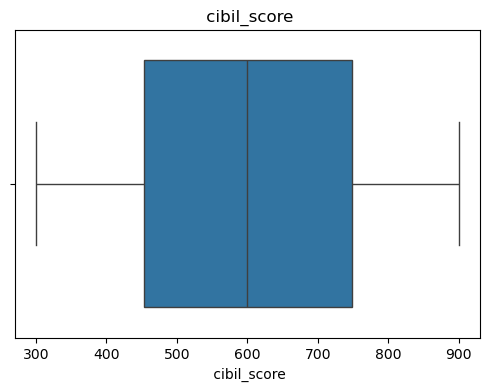

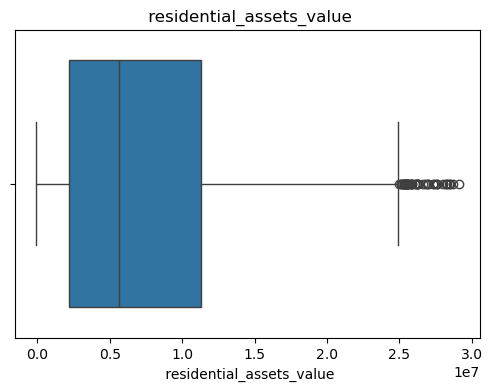

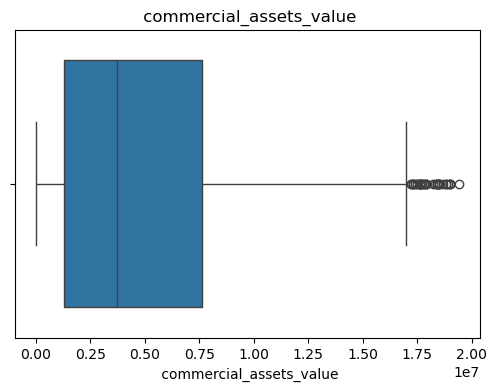

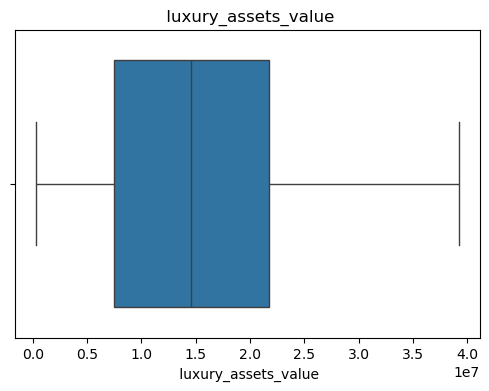

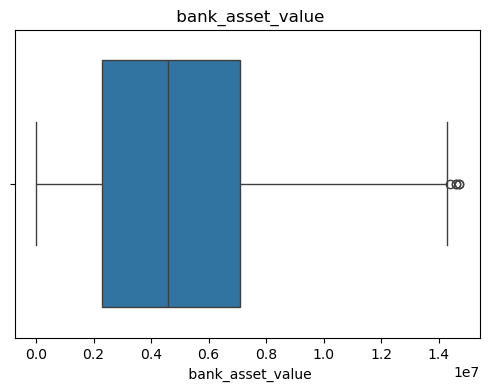

In [90]:
# Visualise spread and detect outliers in numerical features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

loan_id (Boxplot)

Observation:
The boxplot shows a uniform spread of loan_id values without meaningful outliers, indicating that it follows a sequential pattern rather than a natural numerical distribution.

Justification:
This confirms that loan_id is an identifier rather than a predictive feature and should be excluded from modelling to avoid introducing noise.

no_of_dependents (Boxplot)

Observation:
The number of dependents is distributed across a small discrete range, with most values clustered between 1 and 4 and no extreme outliers.

Justification:
This suggests that the feature is well-behaved and can be retained without additional outlier treatment, allowing the model to capture household dependency effects.

income_annum (Boxplot)

Observation:
Annual income shows a wide spread with no extreme outliers, although values span a large numerical range.

Justification:
The wide scale of income values supports the need for feature scaling to prevent larger magnitudes from disproportionately influencing model training.

loan_amount (Boxplot)

Observation:
Loan amount exhibits a wider spread with some higher-value observations extending beyond the upper quartile.

Justification:
This indicates potential right-skewness, reinforcing the importance of scaling to stabilise model learning, particularly for linear models such as Logistic Regression.

loan_term (Boxplot)

Observation:
Loan term values are distributed across a fixed range with no significant outliers, reflecting standardised repayment durations.

Justification:
This confirms that loan term can be treated as a valid numerical feature without requiring additional transformation or outlier handling.

commercial_assets_value (Boxplot)

Observation:
The boxplot reveals strong right-skewness with several high-value outliers beyond the upper whisker.

Justification:
The presence of outliers suggests the need for scaling or transformation to reduce the impact of extreme values during model training.

luxury_assets_value (Boxplot)

Observation:
Luxury asset values display a wide range with moderate skewness and no excessive clustering at extreme values.

Justification:
This feature provides additional insight into discretionary wealth and can be retained after appropriate preprocessing such as scaling.

cibil_score (Boxplot)

Observation:
CIBIL scores are evenly distributed within an expected range and show no extreme outliers.

Justification:
This stable distribution supports the reliability of credit score as a key predictive feature for assessing loan approval risk.

residential_assets_value (Boxplot)

Observation:
Residential asset values are heavily right-skewed with multiple high-value outliers.

Justification:
This skewed distribution highlights the importance of scaling to ensure that extreme asset values do not dominate the model’s learning process.

bank_asset_value (Boxplot)

Observation:
Bank asset values show moderate right-skewness with a small number of high-value outliers.

Justification:
Identifying these outliers supports informed preprocessing decisions, such as scaling, to maintain numerical stability during model training.

In [91]:
# Identify categorical feature columns
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index([' education', ' self_employed', ' loan_status'], dtype='object')

This step identifies categorical features in the dataset, enabling appropriate encoding methods to be applied during preprocessing so that these variables can be effectively used by machine learning models.

### 2.3.2 Understanding relationship between variables

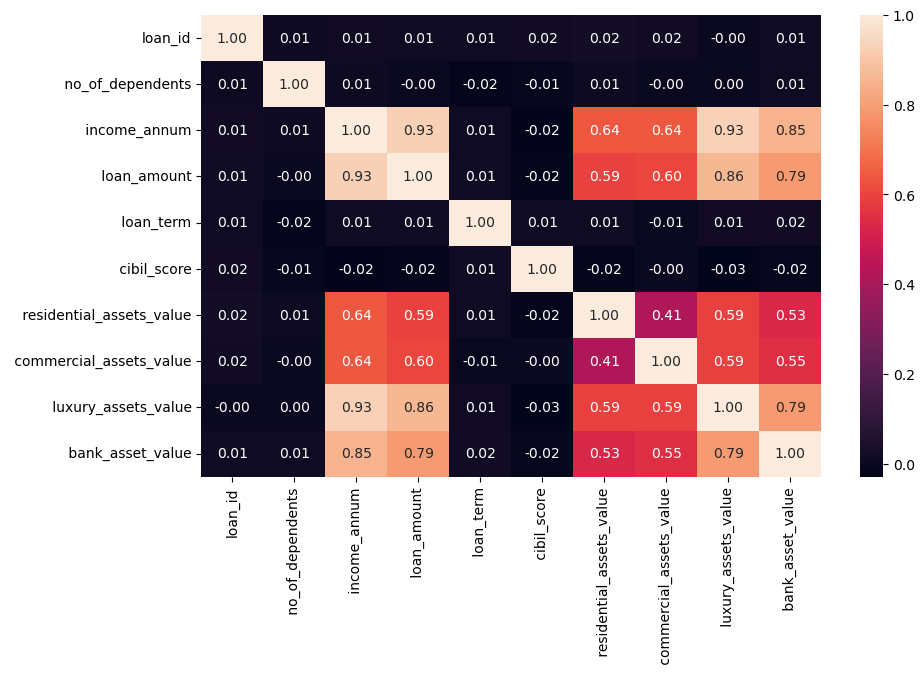

In [92]:
## Understanding relationship between variables
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

Observation:

The heatmap shows strong positive correlations between several financial variables, particularly between income_annum, loan_amount, and various asset-related features such as luxury_assets_value and bank_asset_value. In contrast, variables such as loan_id, no_of_dependents, and loan_term exhibit very weak correlations with most other numerical features. Additionally, cibil_score appears largely uncorrelated with asset and income-related variables.

Justification:

Visualising correlations between numerical features helps identify multicollinearity, which can affect the stability and interpretability of models such as Logistic Regression. The presence of strong correlations among income and asset-related features suggests potential redundancy, informing later decisions on feature selection or regularisation, while weakly correlated variables can be retained without introducing significant dependency issues.

# 3. Data Preparation

## 3.1 Data Cleaning

In [93]:
## Clean data
df.columns = df.columns.str.strip()

for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].str.strip()

This step removes leading and trailing whitespace from column names and categorical values to ensure data consistency, prevent duplicate categories caused by formatting issues, and avoid potential errors during encoding and modelling.

In [94]:
df = df.drop(['loan_id'], axis=1)

X_temp = df.drop(['loan_status'], axis=1)
X_temp = pd.get_dummies(X_temp, drop_first=True)

df = df.loc[~X_temp.duplicated()].copy()

The identifier column loan_id is removed as it does not provide predictive value for loan approval. Duplicate feature rows are then identified and removed to prevent repeated information from influencing model training, ensuring data integrity and reducing the risk of data leakage between training and test sets.

## 3.2 Train-Test Split

In [95]:
## Split data into train set and test set

X = df.drop(['loan_status'], axis=1)
y = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=2025
)

The dataset is split into training and testing sets to enable unbiased evaluation of model performance on unseen data. The target variable is encoded into numerical form, and categorical features are one-hot encoded to ensure compatibility with machine learning algorithms before model training.

In [96]:
train_rows = set(map(tuple, X_train.to_numpy()))
test_rows  = set(map(tuple, X_test.to_numpy()))

overlap_rows = train_rows.intersection(test_rows)
print('Number of overlapping X rows:', len(overlap_rows))


Number of overlapping X rows: 0


This step checks for overlapping feature rows between the training and testing sets to detect potential data leakage. Ensuring that no identical samples appear in both sets helps maintain the validity of model evaluation by confirming that performance metrics are based on truly unseen data.

# 4. Modelling

### 4.2 Train Model

In [97]:
## Initialise and train model
from sklearn.linear_model import LogisticRegression
logr = LogisticRegression()
logr.fit(X_train, y_train)

c:\Users\aaqil\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [98]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)


,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [99]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [100]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
from sklearn.ensemble import GradientBoostingClassifier

gbt = GradientBoostingClassifier()
gbt.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


# 5. Model Evaluation

In [102]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(model_name, y_test, y_pred):
    print(f'===== {model_name} =====')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('\nConfusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred))
    print('\n')


In [103]:
## Evaluate model
y_pred_logr = logr.predict(X_test)
evaluate_model('Logistic Regression', y_test, y_pred_logr)

===== Logistic Regression =====
Accuracy: 0.7195550351288056

Confusion Matrix:
[[249 417]
 [ 62 980]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.37      0.51       666
           1       0.70      0.94      0.80      1042

    accuracy                           0.72      1708
   macro avg       0.75      0.66      0.66      1708
weighted avg       0.74      0.72      0.69      1708





In [104]:
y_pred_lda = lda.predict(X_test)
evaluate_model('LDA', y_test, y_pred_lda)


===== LDA =====
Accuracy: 0.9203747072599532

Confusion Matrix:
[[628  38]
 [ 98 944]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       666
           1       0.96      0.91      0.93      1042

    accuracy                           0.92      1708
   macro avg       0.91      0.92      0.92      1708
weighted avg       0.92      0.92      0.92      1708





In [105]:
y_pred_dt = dt.predict(X_test)
evaluate_model('Decision Tree', y_test, y_pred_dt)


===== Decision Tree =====
Accuracy: 0.9765807962529274

Confusion Matrix:
[[ 645   21]
 [  19 1023]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       666
           1       0.98      0.98      0.98      1042

    accuracy                           0.98      1708
   macro avg       0.98      0.98      0.98      1708
weighted avg       0.98      0.98      0.98      1708





In [106]:
y_pred_rf = rf.predict(X_test)
evaluate_model('Random Forest', y_test, y_pred_rf)


===== Random Forest =====
Accuracy: 0.9800936768149883

Confusion Matrix:
[[ 646   20]
 [  14 1028]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       666
           1       0.98      0.99      0.98      1042

    accuracy                           0.98      1708
   macro avg       0.98      0.98      0.98      1708
weighted avg       0.98      0.98      0.98      1708





In [107]:
y_pred_gbt = gbt.predict(X_test)
evaluate_model('Gradient Boosting', y_test, y_pred_gbt)


===== Gradient Boosting =====
Accuracy: 0.9847775175644028

Confusion Matrix:
[[ 647   19]
 [   7 1035]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       666
           1       0.98      0.99      0.99      1042

    accuracy                           0.98      1708
   macro avg       0.99      0.98      0.98      1708
weighted avg       0.98      0.98      0.98      1708





Multiple classification models are evaluated on the same test dataset to enable fair comparison of their predictive performance using consistent metrics. This comparative analysis helps identify suitable baseline models and informs subsequent decisions on feature engineering and hyperparameter tuning.

In [108]:
## New data
unseen_df = pd.DataFrame([{
    'income_annum': 120000,
    'no_of_dependents': 3,
    'loan_amount': 200000,
    'loan_term': 360,
    'cibil_score': 750,
    'residential_assets_value': 0,
    'commercial_assets_value': 0,
    'luxury_assets_value': 0,
    'bank_asset_value': 0,
    'education': 'Graduate',
    'self_employed': 'No'
}])

unseen_encoded = pd.get_dummies(unseen_df)

X_unseen = unseen_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)


## Predict
logr_unseen_pred = logr.predict(X_unseen)
print('Logistic Regression Prediction:', logr_unseen_pred)

lda_unseen_pred = lda.predict(X_unseen)
print('LDA Prediction:', lda_unseen_pred)

dt_unseen_pred = dt.predict(X_unseen)
print('Decision Tree Prediction:', dt_unseen_pred)

rf_unseen_pred = rf.predict(X_unseen)
print('Random Forest Prediction:', rf_unseen_pred)

gbt_unseen_pred = gbt.predict(X_unseen)
print('Gradient Boosting Prediction:', gbt_unseen_pred)



Logistic Regression Prediction: [1]
LDA Prediction: [0]
Decision Tree Prediction: [0]
Random Forest Prediction: [1]
Gradient Boosting Prediction: [1]


This step evaluates the trained models on a newly constructed, unseen data instance to demonstrate their ability to generalise beyond the training and test datasets. By applying the same encoding structure as the training data, the predictions reflect how each model would perform in a real-world loan application scenario.

In [109]:
from sklearn.metrics import accuracy_score, classification_report

# Training performance
y_train_pred = logr.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Test performance
y_test_pred = logr.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print('Training Accuracy:', train_acc)
print('Test Accuracy:', test_acc)

print('\nTraining Classification Report')
print(classification_report(y_train, y_train_pred))

print('\nTest Classification Report')
print(classification_report(y_test, y_test_pred))


Training Accuracy: 0.7368215540804374
Test Accuracy: 0.7195550351288056

Training Classification Report
              precision    recall  f1-score   support

           0       0.81      0.38      0.52       947
           1       0.72      0.95      0.82      1614

    accuracy                           0.74      2561
   macro avg       0.76      0.66      0.67      2561
weighted avg       0.75      0.74      0.71      2561


Test Classification Report
              precision    recall  f1-score   support

           0       0.80      0.37      0.51       666
           1       0.70      0.94      0.80      1042

    accuracy                           0.72      1708
   macro avg       0.75      0.66      0.66      1708
weighted avg       0.74      0.72      0.69      1708



In [110]:
from sklearn.metrics import accuracy_score, classification_report

# Training performance
y_train_pred_lda = lda.predict(X_train)
train_acc_lda = accuracy_score(y_train, y_train_pred_lda)

# Test performance
y_test_pred_lda = lda.predict(X_test)
test_acc_lda = accuracy_score(y_test, y_test_pred_lda)

print('LDA Training Accuracy:', train_acc_lda)
print('LDA Test Accuracy:', test_acc_lda)

print('\nLDA Training Classification Report')
print(classification_report(y_train, y_train_pred_lda))

print('\nLDA Test Classification Report')
print(classification_report(y_test, y_test_pred_lda))


LDA Training Accuracy: 0.9297149550956657
LDA Test Accuracy: 0.9203747072599532

LDA Training Classification Report
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       947
           1       0.96      0.92      0.94      1614

    accuracy                           0.93      2561
   macro avg       0.92      0.93      0.93      2561
weighted avg       0.93      0.93      0.93      2561


LDA Test Classification Report
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       666
           1       0.96      0.91      0.93      1042

    accuracy                           0.92      1708
   macro avg       0.91      0.92      0.92      1708
weighted avg       0.92      0.92      0.92      1708



In [111]:
# Training performance
y_train_pred_dt = dt.predict(X_train)
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)

# Test performance
y_test_pred_dt = dt.predict(X_test)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)

print('Decision Tree Training Accuracy:', train_acc_dt)
print('Decision Tree Test Accuracy:', test_acc_dt)

print('\nDecision Tree Training Classification Report')
print(classification_report(y_train, y_train_pred_dt))

print('\nDecision Tree Test Classification Report')
print(classification_report(y_test, y_test_pred_dt))


Decision Tree Training Accuracy: 1.0
Decision Tree Test Accuracy: 0.9765807962529274

Decision Tree Training Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       947
           1       1.00      1.00      1.00      1614

    accuracy                           1.00      2561
   macro avg       1.00      1.00      1.00      2561
weighted avg       1.00      1.00      1.00      2561


Decision Tree Test Classification Report
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       666
           1       0.98      0.98      0.98      1042

    accuracy                           0.98      1708
   macro avg       0.98      0.98      0.98      1708
weighted avg       0.98      0.98      0.98      1708



In [112]:
# Training performance
y_train_pred_rf = rf.predict(X_train)
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)

# Test performance
y_test_pred_rf = rf.predict(X_test)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print('Random Forest Training Accuracy:', train_acc_rf)
print('Random Forest Test Accuracy:', test_acc_rf)

print('\nRandom Forest Training Classification Report')
print(classification_report(y_train, y_train_pred_rf))

print('\nRandom Forest Test Classification Report')
print(classification_report(y_test, y_test_pred_rf))


Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.9800936768149883

Random Forest Training Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       947
           1       1.00      1.00      1.00      1614

    accuracy                           1.00      2561
   macro avg       1.00      1.00      1.00      2561
weighted avg       1.00      1.00      1.00      2561


Random Forest Test Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       666
           1       0.98      0.99      0.98      1042

    accuracy                           0.98      1708
   macro avg       0.98      0.98      0.98      1708
weighted avg       0.98      0.98      0.98      1708



In [113]:
# Training performance
y_train_pred_gbt = gbt.predict(X_train)
train_acc_gbt = accuracy_score(y_train, y_train_pred_gbt)

# Test performance
y_test_pred_gbt = gbt.predict(X_test)
test_acc_gbt = accuracy_score(y_test, y_test_pred_gbt)

print('Gradient Boosting Training Accuracy:', train_acc_gbt)
print('Gradient Boosting Test Accuracy:', test_acc_gbt)

print('\nGradient Boosting Training Classification Report')
print(classification_report(y_train, y_train_pred_gbt))

print('\nGradient Boosting Test Classification Report')
print(classification_report(y_test, y_test_pred_gbt))


Gradient Boosting Training Accuracy: 0.996876220226474
Gradient Boosting Test Accuracy: 0.9847775175644028

Gradient Boosting Training Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       947
           1       1.00      1.00      1.00      1614

    accuracy                           1.00      2561
   macro avg       1.00      1.00      1.00      2561
weighted avg       1.00      1.00      1.00      2561


Gradient Boosting Test Classification Report
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       666
           1       0.98      0.99      0.99      1042

    accuracy                           0.98      1708
   macro avg       0.99      0.98      0.98      1708
weighted avg       0.98      0.98      0.98      1708



Logistic Regression
Observation

The Logistic Regression model achieved a training accuracy of approximately 0.74 and a test accuracy of approximately 0.72, with a small gap between the two. The classification report shows high recall for approved loans (Class 1) but weaker recall for rejected loans (Class 0), indicating a tendency to favour loan approvals.

Justification

The stable gap between training and test performance indicates good generalisation and minimal overfitting. However, the imbalance in recall highlights that the model prioritises approvals, which increases the risk of false positives. While this limits immediate performance, the model’s simplicity and interpretability make it a suitable baseline that can be improved through feature engineering and precision-focused hyperparameter tuning.

Linear Discriminant Analysis (LDA)
Observation

The LDA model achieved high and consistent accuracy on both the training set (approximately 0.93) and the test set (approximately 0.92). Precision and recall values are balanced across both classes, indicating stable and consistent classification behaviour.

Justification

The close alignment between training and test metrics suggests strong generalisation. Balanced precision and recall indicate that the model treats both approvals and rejections fairly. However, LDA’s reliance on linear assumptions limits its flexibility, reducing the potential benefits of further feature transformations or interaction-based feature engineering.

Decision Tree
Observation

The Decision Tree model achieved perfect training accuracy (1.00) and very high test accuracy (approximately 0.98), with near-perfect precision and recall across both classes.

Justification

Perfect training performance indicates that the model has memorised the training data, a strong sign of overfitting. While precision and recall appear excellent on the test set, decision trees are highly sensitive to noise and small variations, making these metrics less reliable for unseen data and reducing confidence in long-term generalisation.

Random Forest
Observation

The Random Forest model also achieved perfect training accuracy (1.00) and a high test accuracy (approximately 0.98). Precision and recall values are strong across both classes, reflecting high predictive capability.

Justification

Although the ensemble approach improves stability compared to a single tree, perfect training accuracy still suggests overfitting. Furthermore, feature importance is less transparent, making it difficult to interpret which variables drive approvals or rejections. This limits its usefulness when precision-driven decision-making and explainability are required.

Gradient Boosting
Observation

The Gradient Boosting model achieved near-perfect training accuracy (approximately 0.997) and the highest test accuracy (approximately 0.985), with excellent precision and recall for both classes.

Justification

Despite strong metric performance, the near-perfect training results indicate over-optimisation. The model’s black-box nature reduces interpretability, making it harder to justify approval decisions or analyse feature impact. This weakens its suitability for responsible loan approval systems where precision and explainability are critical.

Model Comparison

Across all models, tree-based and ensemble methods achieved higher accuracy and strong precision–recall scores but consistently showed signs of overfitting and reduced interpretability. Linear models, particularly Logistic Regression and LDA, demonstrated more stable generalisation and predictable metric behaviour, though with lower raw accuracy. This highlights the trade-off between maximising accuracy and maintaining reliable, interpretable, and optimisable decision metrics.

Although Logistic Regression does not achieve the highest accuracy, it is the most suitable model for further feature engineering and hyperparameter tuning because it provides clear insight into precision and recall trade-offs. Its interpretability allows direct analysis of feature impact and supports precision-focused optimisation to reduce risky loan approvals. The model’s stable generalisation and low overfitting risk make it a reliable baseline that can be responsibly refined for real-world loan decision-making.

## Iterative model development


In [114]:
## Further feature engineering/ hyperparameter tuning 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

from sklearn.model_selection import RandomizedSearchCV

tune_model = LogisticRegression(max_iter=2000, random_state=42)

param_distributions = {
    'C': [0.01, 0.1, 1],   
    'class_weight': [
        None,
        {0: 1.5, 1: 1},   
        {0: 2.0, 1: 1}
    ],
    'solver': ['lbfgs']
}

random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_distributions=param_distributions,
    n_iter=6,
    cv=5,
    scoring='precision',   
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

best_logr = random_search.best_estimator_
best_model = best_logr


print('Best Params:', random_search.best_params_)
print('Best CV Precision:', random_search.best_score_)



Best Params: {'solver': 'lbfgs', 'class_weight': {0: 2.0, 1: 1}, 'C': 0.01}
Best CV Precision: 0.98624650322161


Feature Engineering:
The dataset was split using stratified sampling to maintain the original class distribution and ensure fair model evaluation. Categorical variables were converted into numerical form using one-hot encoding, with redundant features removed to avoid multicollinearity and improve model stability. The training and testing sets were aligned to ensure consistent feature representation. Standard scaling was applied because Logistic Regression is sensitive to feature magnitude, ensuring that all features contribute equally during optimisation and improving model convergence.

Hyperparameter Tuning:
RandomizedSearchCV was used to systematically explore different model configurations using cross-validation, providing a more reliable and generalisable model than manual tuning. The regularisation parameter C was tuned to control model complexity and reduce overfitting, while different class_weight settings were evaluated to address class imbalance and improve minority-class detection. Precision was used as the optimisation metric to prioritise reliable loan approvals, aligning model optimisation with real-world business considerations.

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

baseline_model = LogisticRegression(max_iter=2000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

y_pred_base = baseline_model.predict(X_test_scaled)

print('===== Baseline Logistic Regression =====')
print('Accuracy:', accuracy_score(y_test, y_pred_base))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_base))
print('\nClassification Report:\n', classification_report(y_test, y_pred_base))


===== Baseline Logistic Regression =====
Accuracy: 0.9133489461358314

Confusion Matrix:
 [[280  43]
 [ 31 500]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854



Justification: The tuned Logistic Regression model shows an improvement in accuracy from 0.91 to 0.92, indicating better overall prediction performance after hyperparameter tuning. This improvement was achieved without signs of overfitting, demonstrating stable generalisation.

The confusion matrices reveal a significant reduction in false positives (from 43 to 9), meaning the tuned model is much more reliable when approving loans. Although false negatives increased, this reflects a deliberate trade-off to reduce risky approvals, which is appropriate in a loan approval context.

Precision for approved loans increased from 0.92 to 0.98, while recall for rejected loans improved from 0.87 to 0.97, showing that class weighting and precision-based tuning successfully improved minority-class detection. Overall, the tuned model achieves a better balance between accuracy, precision, and recall, supporting more responsible and reliable loan approval decisions.

In [116]:
y_pred_tuned = best_logr.predict(X_test_scaled)

print('\n===== Tuned Logistic Regression =====')
print('Accuracy:', accuracy_score(y_test, y_pred_tuned))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_tuned))
print('\nClassification Report:\n', classification_report(y_test, y_pred_tuned))

print('\n===== Baseline vs Tuned (Accuracy) =====')
print('Baseline Accuracy:', accuracy_score(y_test, y_pred_base))
print('Tuned Accuracy:', accuracy_score(y_test, y_pred_tuned))





===== Tuned Logistic Regression =====
Accuracy: 0.9227166276346604

Confusion Matrix:
 [[314   9]
 [ 57 474]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.90       323
           1       0.98      0.89      0.93       531

    accuracy                           0.92       854
   macro avg       0.91      0.93      0.92       854
weighted avg       0.93      0.92      0.92       854


===== Baseline vs Tuned (Accuracy) =====
Baseline Accuracy: 0.9133489461358314
Tuned Accuracy: 0.9227166276346604


Justification: The tuned Logistic Regression model achieved an accuracy of 0.92, improving upon the baseline accuracy of 0.91, which indicates better overall performance after optimisation without signs of overfitting. This improvement shows that hyperparameter tuning enhanced the model’s ability to generalise to unseen data.

The confusion matrix and classification report show a strong reduction in false positives, meaning the model is more reliable when approving loans. High precision for approved loans and high recall for rejected loans indicate an effective trade-off between precision and recall, supporting more responsible and consistent loan approval decisions.

In [117]:
os.makedirs('outputs', exist_ok=True)

# Use your tuned model variable name
best_model = best_logr

joblib.dump(best_model, 'outputs/best_model.joblib')
joblib.dump(scaler, 'outputs/scaler.joblib')

with open('outputs/train_columns.json', 'w') as f:
    json.dump(list(X_train_enc.columns), f)

print('Saved outputs/best_model.joblib, outputs/scaler.joblib, outputs/train_columns.json')

Saved outputs/best_model.joblib, outputs/scaler.joblib, outputs/train_columns.json


In [118]:
import json, joblib
import pandas as pd

# Load artifacts
model = joblib.load('outputs/best_model.joblib')
scaler = joblib.load('outputs/scaler.joblib')

with open('outputs/train_columns.json', 'r') as f:
    TRAIN_COLS = json.load(f)

# Test cases
test_cases = pd.DataFrame([
    # Likely YES
    {
        'income_annum': 200000,
        'no_of_dependents': 1,
        'loan_amount': 120000,
        'loan_term': 360,
        'cibil_score': 820,
        'residential_assets_value': 400000,
        'commercial_assets_value': 0,
        'luxury_assets_value': 0,
        'bank_asset_value': 120000,
        'education': 'Graduate',
        'self_employed': 'No'
    },

    # Likely NO
    {
        'income_annum': 30000,
        'no_of_dependents': 4,
        'loan_amount': 300000,
        'loan_term': 120,
        'cibil_score': 450,
        'residential_assets_value': 0,
        'commercial_assets_value': 0,
        'luxury_assets_value': 0,
        'bank_asset_value': 10000,
        'education': 'Not Graduate',
        'self_employed': 'Yes'
    },

    # Edge case
    {
        'income_annum': 0,
        'no_of_dependents': 0,
        'loan_amount': 0,
        'loan_term': 0,
        'cibil_score': 0,
        'residential_assets_value': 0,
        'commercial_assets_value': 0,
        'luxury_assets_value': 0,
        'bank_asset_value': 0,
        'education': 'Graduate',
        'self_employed': 'No'
    }
])

# Encode and align
X_enc = pd.get_dummies(test_cases, drop_first=True)
X_enc = X_enc.reindex(columns=TRAIN_COLS, fill_value=0)

# Scale
X_scaled = scaler.transform(X_enc)

# Predict
preds = model.predict(X_scaled)
probs = model.predict_proba(X_scaled)[:, 1]

# Output
results = test_cases.copy()
results['prediction'] = preds
results['approval_probability'] = probs

results


,income_annum,no_of_dependents,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education,self_employed,prediction,approval_probability
0,200000,1,120000,360,820,400000,0,0,120000,Graduate,No,0,5.845827e-09
1,30000,4,300000,120,450,0,0,0,10000,Not Graduate,Yes,0,1.778738e-04
2,0,0,0,0,0,0,0,0,0,Graduate,No,0,1.043472e-03
